In [2]:
#0. 작업 준비
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#데이터 분할
from sklearn.model_selection import train_test_split
#모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Input,Dense,Conv2D,MaxPooling2D,Dropout,SimpleRNN,LSTM,GRU,BatchNormalization
from keras.optimizers import Adam,RMSprop,SGD,Adagrad
from keras.losses import binary_crossentropy,categorical_crossentropy,sparse_categorical_crossentropy,mean_squared_error
#모델 학습
from keras.callbacks import EarlyStopping,ModelCheckpoint
#모델 로드
from keras.models import load_model
#성능검토
from sklearn.metrics import r2_score,classification_report,f1_score,mean_squared_error
from tensorflow import truediv

In [3]:
from keras.datasets import fashion_mnist
(x_data, y_data),(tt_x, tt_y) = fashion_mnist.load_data()

In [4]:
e_x_data = x_data / 255.0
e_tt_x = tt_x / 255.0

In [5]:
tr_x, val_x, tr_y, val_y = train_test_split(e_x_data, y_data, train_size=0.8, stratify=y_data)

In [6]:
from keras.layers import Flatten
from keras.regularizers import l2

m = Sequential()
m.add(Input(shape=tr_x.shape[1:]))
m.add(Flatten())
m.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
m.add(BatchNormalization())
m.add(Dropout(0.3))
m.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
m.add(BatchNormalization())
m.add(Dropout(0.3))
m.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
m.add(BatchNormalization())
m.add(Dropout(0.3))
m.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
m.add(BatchNormalization())
m.add(Dropout(0.3))
m.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
m.add(Dense(10, activation='softmax'))

m.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,866 (663.54 KB)

 Trainable params: 168,842 (659.54 KB)

 Non-trainable params: 1,024 (4.00 KB)

In [7]:
from keras.optimizers import Adam
adam = Adam(0.0001)

In [8]:
m.compile(loss='sparse_categorical_crossentropy', optimizer=adam, metrics=['acc'])

In [9]:
es = EarlyStopping(patience=10, verbose=1, mode='auto', restore_best_weights=True)
ck = ModelCheckpoint('best_m.keras', save_best_only=True, verbose=1)

In [10]:
hy = m.fit(tr_x, tr_y, validation_data=(val_x, val_y), epochs=100, callbacks=[es, ck])

Epoch 1/100
1495/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.4038 - loss: 8.4546
Epoch 1: val_loss improved from inf to 5.69224, saving model to best_m.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.4044 - loss: 8.4505 - val_acc: 0.7856 - val_loss: 5.6922
Epoch 2/100
1490/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.7291 - loss: 5.3430
Epoch 2: val_loss improved from 5.69224 to 3.70049, saving model to best_m.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.7293 - loss: 5.3392 - val_acc: 0.8271 - val_loss: 3.7005
Epoch 3/100
1466/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.7794 - loss: 3.4957
Epoch 3: val_loss improved from 3.70049 to 2.39853, saving model to best_m.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.7796 - loss: 3.4877 - val_acc: 0.8398 - val_loss: 2.3985
Epoch 4/100
1472/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.8062 - loss: 2.3103
Epoch 4: val_loss improved from 2.39853 to 1.64064, saving model to best_m.keras
1500/1500 ━━━━━━━

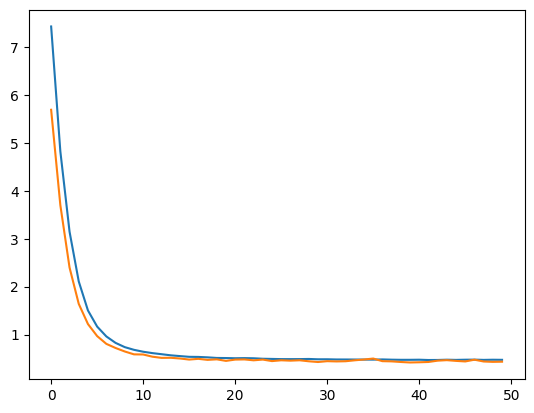

In [11]:
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])